In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("heart.csv")

In [36]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [37]:
df.shape

(918, 12)

In [38]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [39]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [40]:
# Descriptive Statistics
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [41]:
# No missing value

In [42]:
# Numerical Value

In [43]:
df_num = df.select_dtypes(['int64','float64'])

In [44]:
df_num = df_num.drop('HeartDisease', axis=1)

In [45]:
df_num.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
0,40,140,289,0,172,0.0
1,49,160,180,0,156,1.0
2,37,130,283,0,98,0.0
3,48,138,214,0,108,1.5
4,54,150,195,0,122,0.0


In [46]:
# Categorical Value

In [47]:
df_cat = df.select_dtypes('object')

In [48]:
df_cat.head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [49]:
# Encoding the Categorical Variables
dummy_var = pd.get_dummies(df_cat, drop_first='true')

In [50]:
dummy_var.head()

,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,True,True,False,False,True,False,False,False,True
1,False,False,True,False,True,False,False,True,False
2,True,True,False,False,False,True,False,False,True
3,False,False,False,False,True,False,True,True,False
4,True,False,True,False,True,False,False,False,True


In [51]:
dummy_var_new = dummy_var.replace({'True':1, 'False':0}).astype(int)

In [52]:
dummy_var_new.head()

,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,1,1,0,0,1,0,0,0,1
1,0,0,1,0,1,0,0,1,0
2,1,1,0,0,0,1,0,0,1
3,0,0,0,0,1,0,1,1,0
4,1,0,1,0,1,0,0,0,1


In [53]:
# Target

In [54]:
y = df['HeartDisease']

In [55]:
y.head()

0    0
1    1
2    0
3    1
4    0
Name: HeartDisease, dtype: int64

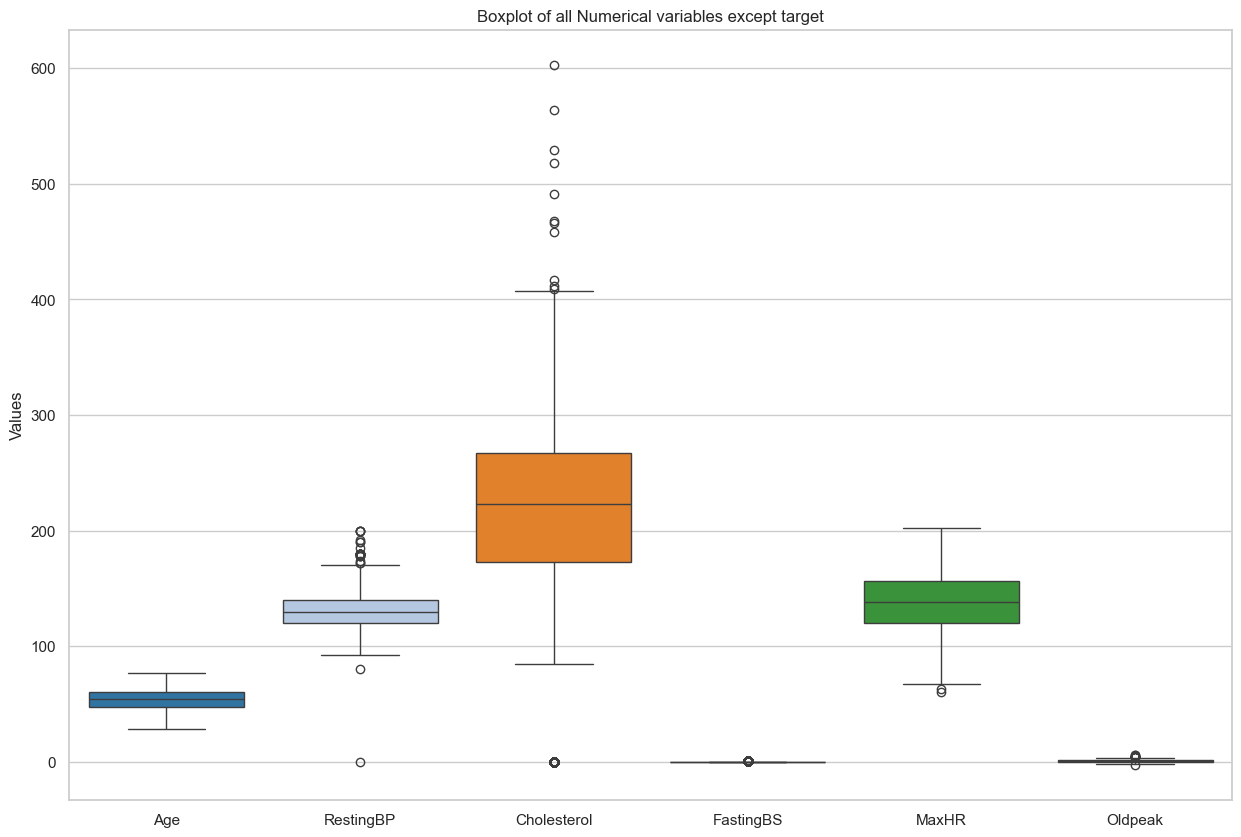

In [56]:
# Boxplot of all numerical variables for checking outliers
sns.set(style="whitegrid")

# Plot boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_num, palette='tab20')
plt.title("Boxplot of all Numerical variables except target")
plt.ylabel("Values")
plt.show()

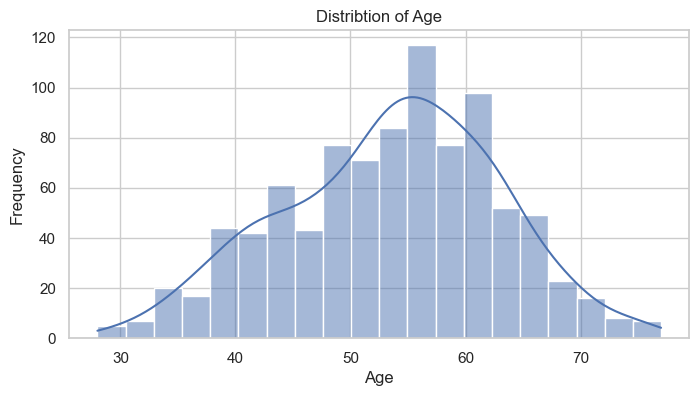

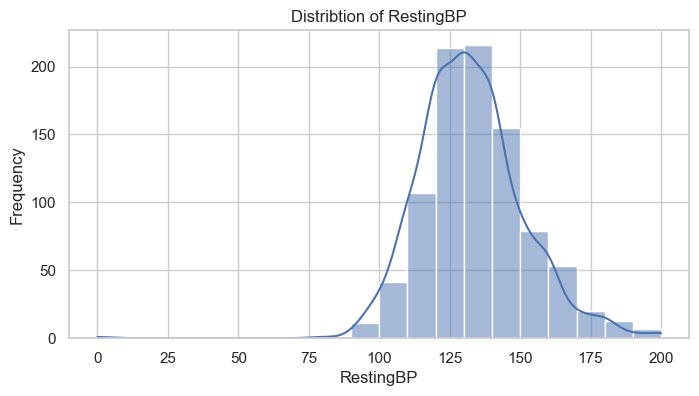

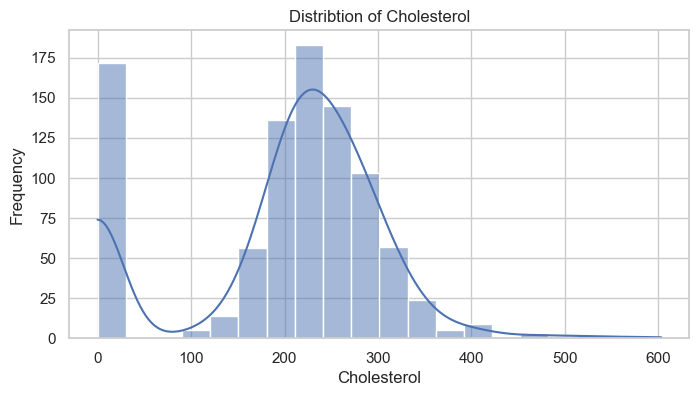

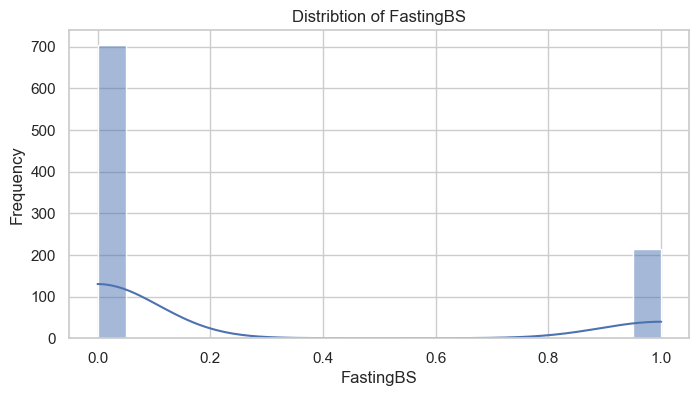

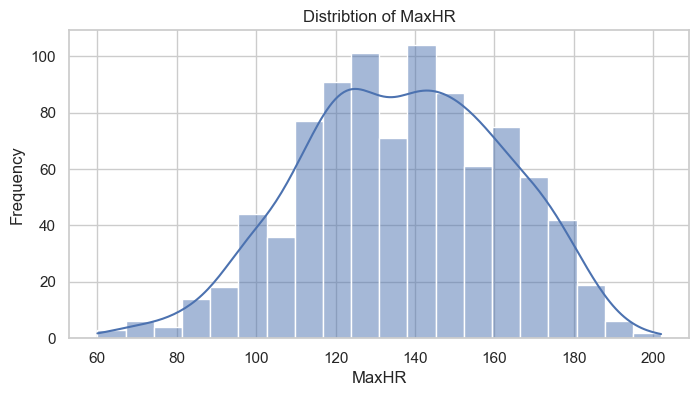

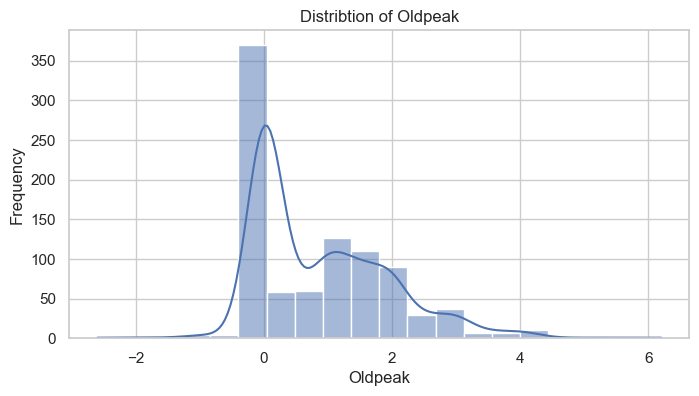

In [57]:
# Histogram plot for all numerical variables to visualize dsitribution of data
sns.set(style="whitegrid")

for col in df_num:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_num[col], kde=True, bins=20)
    plt.title(f"Distribtion of {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [58]:
### RestingBP and Cholestrol have outliers
### Need to perform outlier_treatment

In [59]:
def outlier_treatment(column):
    Q1, Q3 = np.percentile(column, [25,75])
    IQR = Q3-Q1
    lower_range = Q1-(1.5*IQR)
    upper_range = Q3+(1.5*IQR)
    return lower_range, upper_range

In [60]:
for col in df_num:
    lr, ur = outlier_treatment(df_num[col])
    df_num[col] = np.where(df_num[col]<lr, lr, df_num[col])
    df_num[col] = np.where(df_num[col]>ur, ur, df_num[col])
    

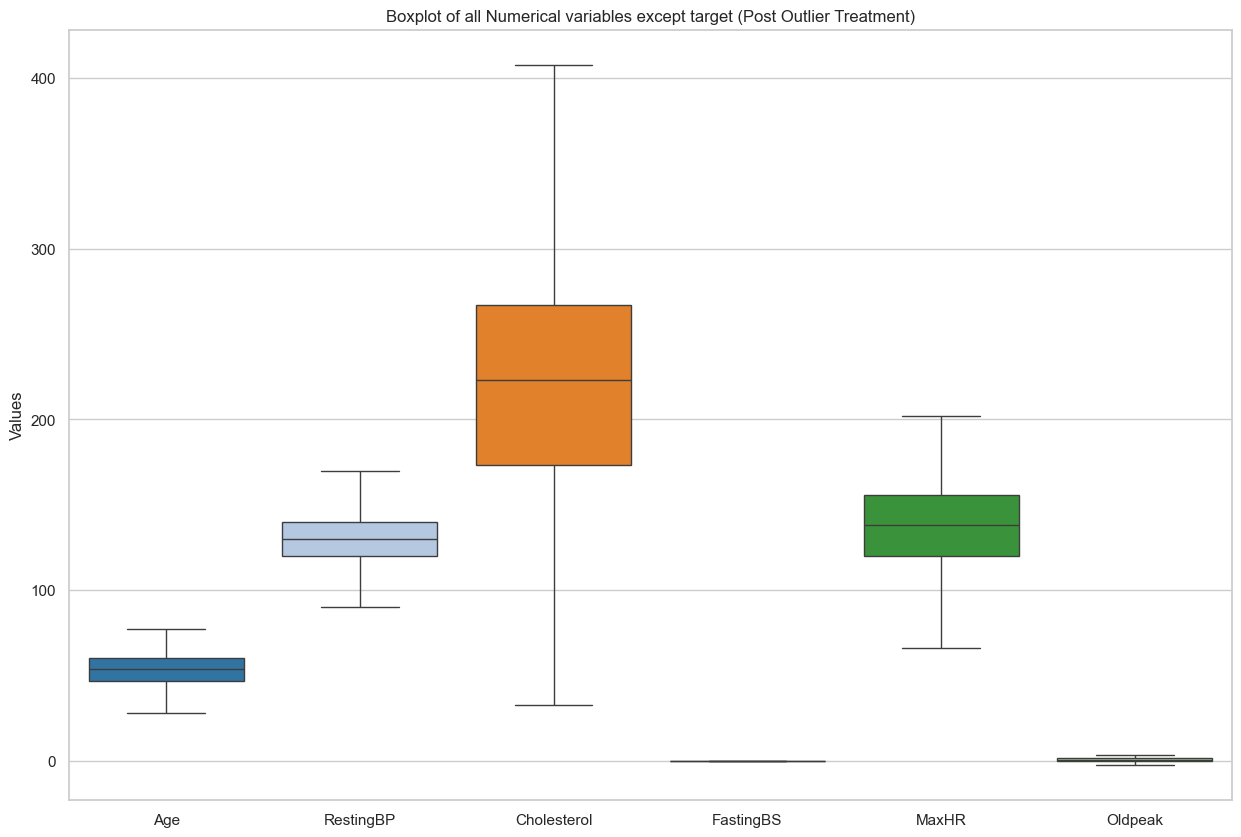

In [61]:
# Boxplot of all numerical variables after outlier treatment
sns.set(style="whitegrid")

# Plot boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_num, palette='tab20')
plt.title("Boxplot of all Numerical variables except target (Post Outlier Treatment)")
plt.ylabel("Values")
plt.show()

In [62]:
features = pd.concat([df_num, dummy_var_new], axis=1)
X = features

In [63]:
features.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40.0,140.0,289.0,0.0,172.0,0.0,1,1,0,0,1,0,0,0,1
1,49.0,160.0,180.0,0.0,156.0,1.0,0,0,1,0,1,0,0,1,0
2,37.0,130.0,283.0,0.0,98.0,0.0,1,1,0,0,0,1,0,0,1
3,48.0,138.0,214.0,0.0,108.0,1.5,0,0,0,0,1,0,1,1,0
4,54.0,150.0,195.0,0.0,122.0,0.0,1,0,1,0,1,0,0,0,1


In [64]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [65]:
# Decision Tree Calssification
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(random_state=42)

# Performing a GridSearchCV based on question requirements
from sklearn.model_selection import GridSearchCV

param_grid ={
    'criterion':['gini','entropy'],
    'max_depth': list(range(5,16)),
    'max_features': ['sqrt','log2'],
    'min_samples_split': list(range(5,11)),
    'min_samples_leaf': list(range(5,11)),
    'max_leaf_nodes': list(range(5,11))  
}

grid_search = GridSearchCV(dt, param_grid, cv=5, n_jobs=1, scoring='accuracy')

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                         'max_features': ['sqrt', 'log2'],
                         'max_leaf_nodes': [5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [5, 6, 7, 8, 9, 10],
                         'min_samples_split': [5, 6, 7, 8, 9, 10]},
             scoring='accuracy')

In [66]:
# Predict 
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [67]:
# Evaluate model performance
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.82      0.76       112
           1       0.86      0.77      0.81       164

    accuracy                           0.79       276
   macro avg       0.79      0.79      0.79       276
weighted avg       0.80      0.79      0.79       276



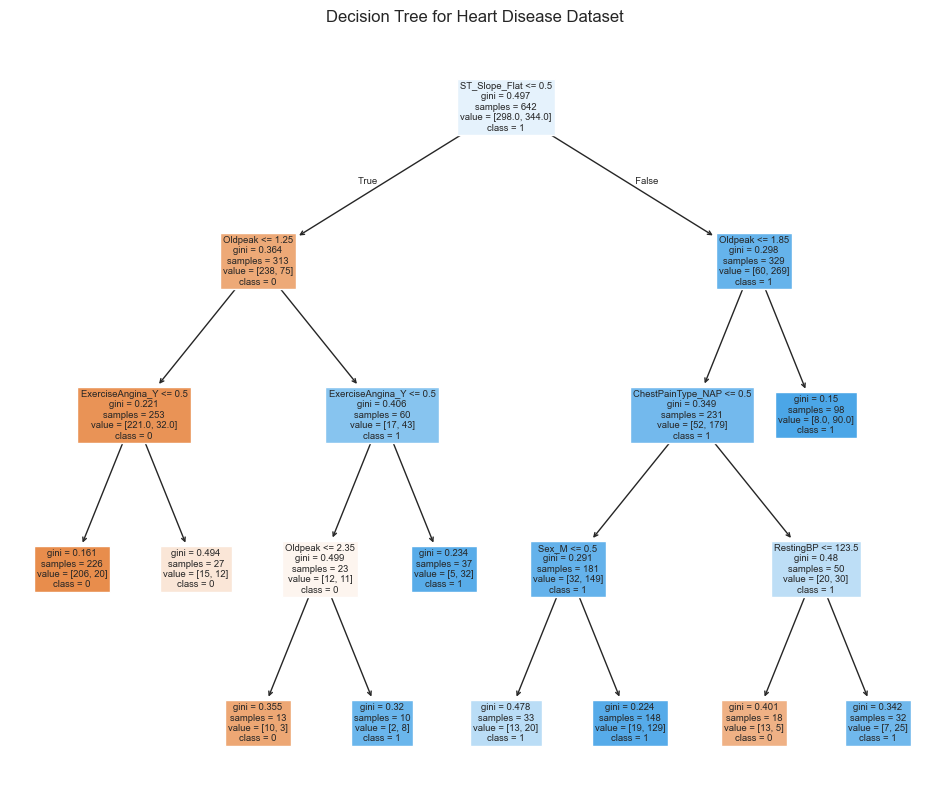

In [68]:
# Visualizing the decision tree
plt.figure(figsize=(12,10))

plot_tree(best_model, feature_names=features.columns.astype(str), class_names=df['HeartDisease'].unique().astype(str), filled=True)
plt.title("Decision Tree for Heart Disease Dataset")
plt.show()

In [73]:
# Decision Tree 

from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(criterion='entropy', random_state=42)

dt1.fit(X_train,y_train)

y1_pred = dt1.predict(X_test)

from sklearn.metrics import classification_report

print("Decison Tree Report:")
print(classification_report(y_test, y1_pred))


Decison Tree Report:
              precision    recall  f1-score   support

           0       0.63      0.80      0.71       112
           1       0.83      0.68      0.75       164

    accuracy                           0.73       276
   macro avg       0.73      0.74      0.73       276
weighted avg       0.75      0.73      0.73       276



In [77]:
# Decision Tree with hyperparameter tunning
from sklearn.tree import DecisionTreeClassifier

dt2 = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)

dt2.fit(X_train, y_train)

y2_pred = dt2.predict(X_test)

from sklearn.metrics import classification_report
print("Decision Tree Report post hyperparameter tunning:")
print(classification_report(y_test, y2_pred))

Decision Tree Report post hyperparameter tunning:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       112
           1       0.85      0.80      0.83       164

    accuracy                           0.80       276
   macro avg       0.79      0.80      0.80       276
weighted avg       0.80      0.80      0.80       276



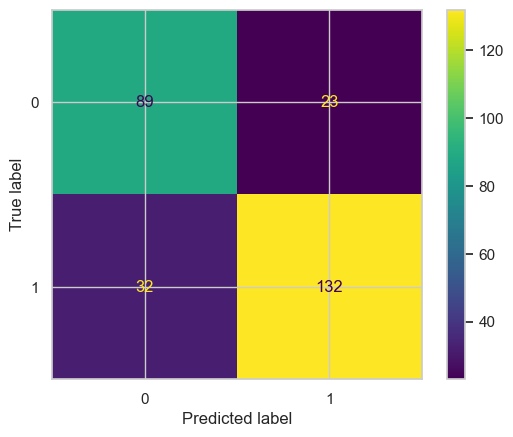

In [81]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y2_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

<Axes: >

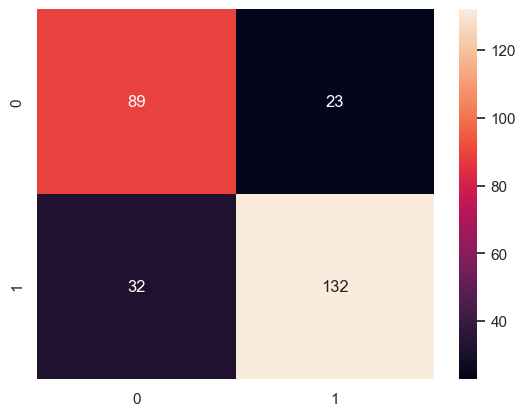

In [84]:
# Confusion Matrix using HeatMap
sns.heatmap(confusion_matrix(y_test, y2_pred), annot=True,  fmt='g')

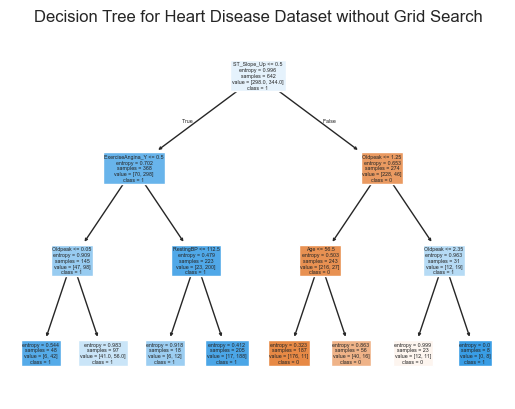

In [85]:
plot_tree(dt2, feature_names=features.columns.astype(str), class_names=df['HeartDisease'].unique().astype(str), filled=True)
plt.title("Decision Tree for Heart Disease Dataset without Grid Search")
plt.show()

In [ ]:
# AUC ROC Curve To do
# from sklearn.metrics import roc_auc_score, roc_score




In [89]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=5, random_state=42)

rf.fit(X_train, y_train)

y3_pred = rf.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y3_pred))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       112
           1       0.87      0.84      0.85       164

    accuracy                           0.83       276
   macro avg       0.82      0.83      0.82       276
weighted avg       0.83      0.83      0.83       276



In [92]:
# AdaBoost 
from sklearn.ensemble import AdaBoostClassifier

adb = AdaBoostClassifier(random_state=42)

adb.fit(X_train, y_train)

y4_pred = adb.predict(X_test)

print("AdaBoost Report:")
print(classification_report(y_test, y4_pred))

AdaBoost Report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       112
           1       0.90      0.84      0.87       164

    accuracy                           0.85       276
   macro avg       0.84      0.85      0.84       276
weighted avg       0.85      0.85      0.85       276



In [96]:
# XGBoost has own library
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

y5_pred = xgb.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y5_pred))

XGBoost Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       112
           1       0.88      0.81      0.84       164

    accuracy                           0.82       276
   macro avg       0.82      0.83      0.82       276
weighted avg       0.83      0.82      0.82       276

